# LASSO

In [2]:
# lasso_computation.py
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Set random seed for reproducibility
np.random.seed(42)

# Simulate financial dataset: 1000 days, 10 technical indicators
n_samples, n_features = 1000, 10
X = np.random.randn(n_samples, n_features)  # Features (e.g., RSI, MACD)
y = X[:, 0] * 0.5 + X[:, 1] * 0.3 + np.random.randn(n_samples) * 0.1  # Target: stock returns

# Create feature names
feature_names = [f"Indicator_{i+1}" for i in range(n_features)]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit LASSO model
lasso = Lasso(alpha=0.1, random_state=42)
lasso.fit(X_scaled, y)

# Predict and compute MSE
y_pred = lasso.predict(X_scaled)
mse = mean_squared_error(y, y_pred)

# Print results
print("LASSO Regression Results:")
print("Selected features (non-zero coefficients):")
for name, coef in zip(feature_names, lasso.coef_):
    if coef != 0:
        print(f"{name}: {coef:.4f}")
print(f"Mean Squared Error: {mse:.4f}")

LASSO Regression Results:
Selected features (non-zero coefficients):
Indicator_1: 0.4075
Indicator_2: 0.2061
Mean Squared Error: 0.0291


### Plotting

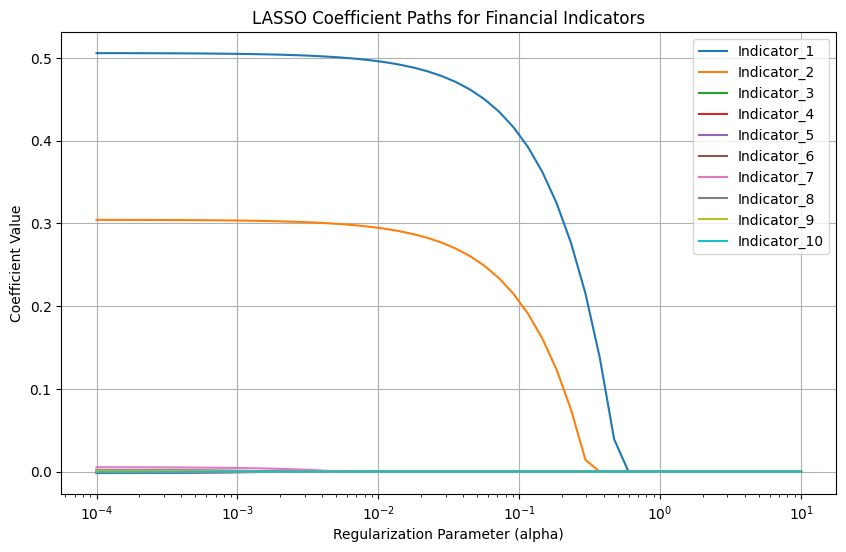

In [4]:
# lasso_illustration.py
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Simulate financial dataset
n_samples, n_features = 1000, 10
X = np.random.randn(n_samples, n_features)
y = X[:, 0] * 0.5 + X[:, 1] * 0.3 + np.random.randn(n_samples) * 0.1
feature_names = [f"Indicator_{i+1}" for i in range(n_features)]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Compute coefficient paths for varying alpha
alphas = np.logspace(-4, 1, 50)  # Range of alpha values
coefs = []
for alpha in alphas:
    lasso = Lasso(alpha=alpha, random_state=42)
    lasso.fit(X_scaled, y)
    coefs.append(lasso.coef_)

# Plot coefficient paths
plt.figure(figsize=(10, 6))
for i in range(n_features):
    plt.plot(alphas, [coef[i] for coef in coefs], label=feature_names[i])
plt.xscale('log')
plt.xlabel('Regularization Parameter (alpha)')
plt.ylabel('Coefficient Value')
plt.title('LASSO Coefficient Paths for Financial Indicators')
plt.legend()
plt.grid(True)
plt.savefig('/Users/alberto/Documents/projects/GWP_1/MLFinance/images/lasso_coefficient_paths.png')
plt.show()

# K-Means clustering

k-Means Clustering Results:
Cluster assignments for the first 10 samples: [2 2 2 2 2 2 2 2 2 2]
Centroid coordinates:
Cluster 0: Return=0.306, Volatility=0.410
Cluster 1: Return=0.498, Volatility=0.620
Cluster 2: Return=0.105, Volatility=0.190


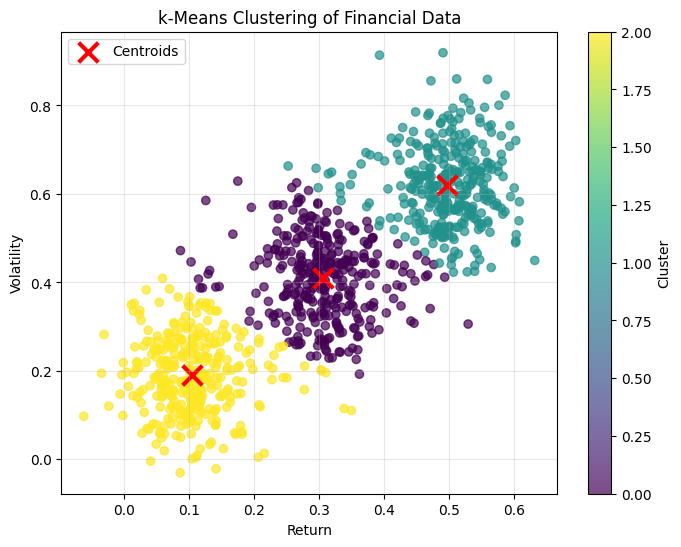

In [13]:
# kmeans_analysis.py
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Simulate financial dataset: 1000 stocks, 2 features (return, volatility)
n_samples = 1000
X = np.concatenate([
    np.random.normal([0.1, 0.2], [0.05, 0.1], (333, 2)),  # Cluster 1
    np.random.normal([0.3, 0.4], [0.05, 0.1], (334, 2)),  # Cluster 2
    np.random.normal([0.5, 0.6], [0.05, 0.1], (333, 2))   # Cluster 3
])

feature_names = ["Return", "Volatility"]

# Apply k-means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

# Print computation results
print("k-Means Clustering Results:")
print("Cluster assignments for the first 10 samples:", cluster_labels[:10])
print("Centroid coordinates:")
for i, centroid in enumerate(kmeans.cluster_centers_):
    print(f"Cluster {i}: Return={centroid[0]:.3f}, Volatility={centroid[1]:.3f}")

# Generate and save illustration
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
           c='red', marker='x', s=200, linewidths=3, label='Centroids')
plt.xlabel("Return")
plt.ylabel("Volatility")
plt.title("k-Means Clustering of Financial Data")
plt.legend()
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.savefig('/Users/alberto/Documents/projects/GWP_1/MLFinance/images/kmeans_clusters.png', 
           dpi=300, bbox_inches='tight')
plt.show()

# PCA

PCA Results:
Explained variance ratio for each component:
Component 0: 0.6073
Component 1: 0.2018
Component 2: 0.0938
Component 3: 0.0626
Component 4: 0.0345
Sample of transformed data (first 5 rows):
       PC_1      PC_2      PC_3      PC_4      PC_5
0 -0.874685  0.164427  0.433486 -0.882185  0.082054
1  0.423836 -1.539277  0.567648  0.253439 -0.197525
2  0.825364  0.412622  0.141343  1.097564  0.776051
3  0.988939  0.974223  0.192060  0.533709  0.620192
4 -2.544030  0.138812 -0.035155  0.822270  0.280861


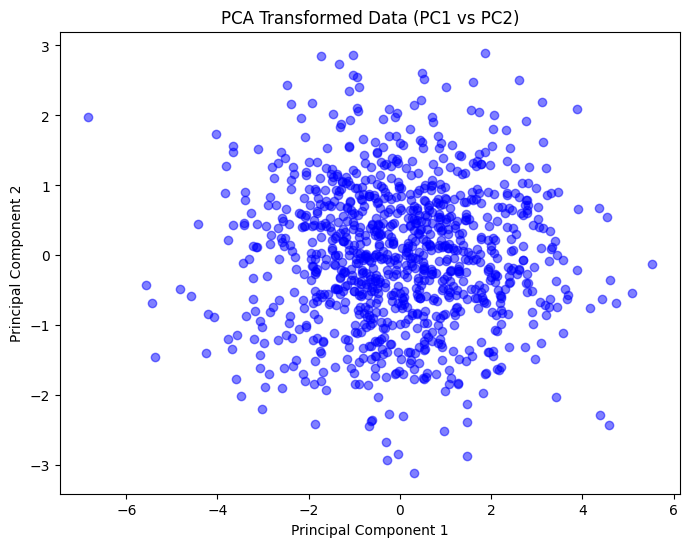

In [14]:
# pca_analysis.py
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Simulate financial dataset: 1000 assets, 5 correlated features (e.g., returns)
n_samples, n_features = 1000, 5
cov_matrix = np.array([[1.0, 0.8, 0.6, 0.4, 0.2],
                       [0.8, 1.0, 0.7, 0.5, 0.3],
                       [0.6, 0.7, 1.0, 0.6, 0.4],
                       [0.4, 0.5, 0.6, 1.0, 0.5],
                       [0.2, 0.3, 0.4, 0.5, 1.0]])
X = np.random.multivariate_normal(np.zeros(5), cov_matrix, n_samples)
feature_names = [f"Asset_{i+1}" for i in range(n_features)]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

# Print computation results
print("PCA Results:")
print("Explained variance ratio for each component:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"Component {i}: {ratio:.4f}")
print("Sample of transformed data (first 5 rows):")
print(pd.DataFrame(X_pca[:5], columns=[f"PC_{i+1}" for i in range(5)]))

# Generate and save illustration: Scree plot
plt.figure(figsize=(8, 6))
plt.plot(range(1, 6), pca.explained_variance_ratio_, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot of PCA for Financial Data")
plt.savefig('/Users/alberto/Documents/projects/GWP_1/MLFinance/images/pca_scree_plot.png')
plt.close()

# Generate and save illustration: Transformed data scatter plot (PC1 vs PC2)
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='blue', alpha=0.5)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Transformed Data (PC1 vs PC2)")
plt.savefig('/Users/alberto/Documents/projects/GWP_1/MLFinance/images/pca_transformed_plot.png')
plt.show()

# Classification trees

Classification Tree Results:
Accuracy on test set: 1.0000
Sample predictions for the first 5 test samples: [0 0 0 0 0]


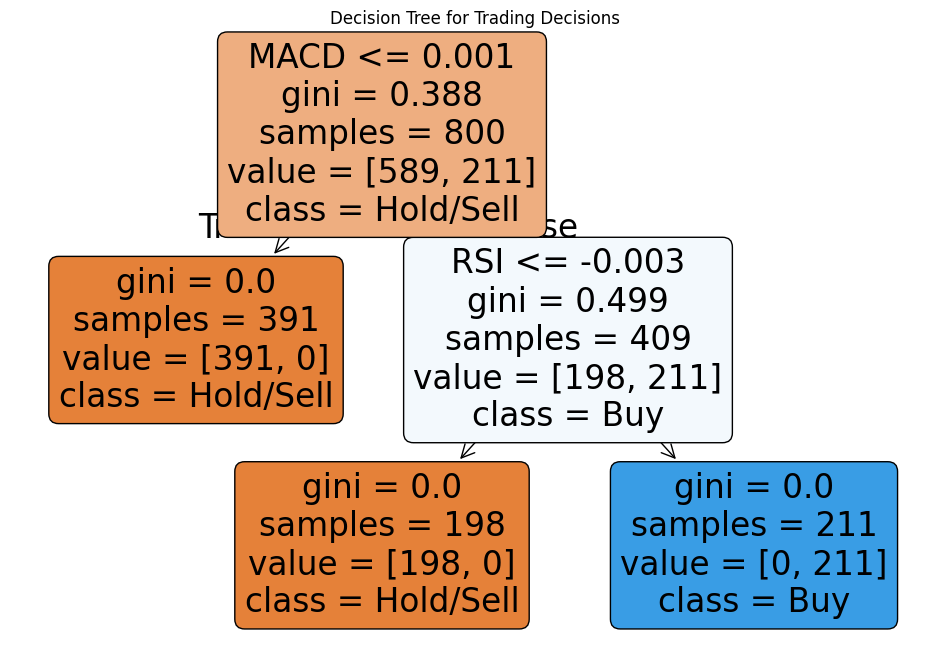

In [15]:
# classification_trees_analysis.py
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Simulate financial dataset: 1000 days, 4 features (e.g., RSI, MACD, volume, price)
n_samples = 1000
X = np.random.randn(n_samples, 4)  # Features: RSI, MACD, volume, price
y = (X[:, 0] > 0) & (X[:, 1] > 0)  # Simple rule: buy if RSI and MACD positive, else hold/sell
y = np.where(y, 1, 0)  # Binary classification: 1 (buy), 0 (hold/sell)
feature_names = ["RSI", "MACD", "Volume", "Price"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply classification tree
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

# Predict and evaluate
y_pred = tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# Print computation results
print("Classification Tree Results:")
print(f"Accuracy on test set: {accuracy:.4f}")
print("Sample predictions for the first 5 test samples:", y_pred[:5])

# Generate and save illustration: Decision tree diagram
plt.figure(figsize=(12, 8))
plot_tree(tree, feature_names=feature_names, class_names=["Hold/Sell", "Buy"], filled=True, rounded=True)
plt.title("Decision Tree for Trading Decisions")
plt.savefig('/Users/alberto/Documents/projects/GWP_1/MLFinance/images/classification_tree.png')
plt.show()